In [2]:
from pathlib import Path
import sys
import os

ROOT = Path(os.getcwd())

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "data"

sys.path.append(str(ROOT))

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, precision_recall_curve, auc, make_scorer, recall_score, roc_auc_score, matthews_corrcoef, classification_report
from sklearn.inspection import permutation_importance

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV,learning_curve, train_test_split, cross_validate

### Data

In [4]:
train_data = pd.read_pickle(DATA/'ml_datasets2/L2_TRAIN.pkl')

features = train_data.iloc[:, :10]

# target = train_data[['source']].copy()
train_data['source'] = train_data['source'].str.split('_').str[0] #less specific nitrogen source
train_data['source_type'] = train_data['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'nitrogen', False: 'carbon'})

**LABEL ENCODING**

In [5]:
# ---- fit encoders ----
le_type     = LabelEncoder().fit(train_data['source_type'])
le_source   = LabelEncoder().fit(train_data['source'])
le_carbon   = LabelEncoder().fit(train_data.loc[train_data['source_type'] == 'carbon',   'source'])
le_nitrogen = LabelEncoder().fit(train_data.loc[train_data['source_type'] == 'nitrogen', 'source'])

# ---- encode labels ----
y_type   = le_type.transform(train_data['source_type'])
y_source = le_source.transform(train_data['source'])

# ---- masks ----
carbon_mask   = train_data['source_type'] == 'carbon'
nitrogen_mask = train_data['source_type'] == 'nitrogen'

# ---- features ----
X = features

# ---- stage 2 subsets ----
X_c = X[carbon_mask.values]
X_n = X[nitrogen_mask.values]

y_c = le_carbon.transform(train_data.loc[carbon_mask, 'source'])
y_n = le_nitrogen.transform(train_data.loc[nitrogen_mask, 'source'])

### Two stage classification predictor

In [6]:
def make_prediction_proba(X, binary_clf, carbon_clf, nitrogen_clf, le_type, le_source, le_carbon, le_nitrogen):
    binary_pred = binary_clf.predict(X).ravel()

    carbon_label = le_type.transform(["carbon"])[0]
    nitrogen_label = le_type.transform(["nitrogen"])[0]

    carbon_idx = np.where(binary_pred == carbon_label)[0]
    nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]
    source_proba = np.zeros((len(X), len(le_source.classes_)))

    if len(carbon_idx) > 0:
        carbon_proba = carbon_clf.predict_proba(X.iloc[carbon_idx])
        carbon_global_idx = le_source.transform(le_carbon.classes_)

        source_proba[np.ix_(carbon_idx, carbon_global_idx)] = carbon_proba

    if len(nitrogen_idx) > 0:
        nitrogen_proba = nitrogen_clf.predict_proba(X.iloc[nitrogen_idx])
        nitrogen_global_idx = le_source.transform(le_nitrogen.classes_)

        source_proba[np.ix_(nitrogen_idx, nitrogen_global_idx)] = nitrogen_proba

    return source_proba

In [7]:
def make_prediction(X, binary_clf, carbon_clf, nitrogen_clf, le_type, le_carbon, le_nitrogen):
    binary_pred = binary_clf.predict(X)

    carbon_label   = le_type.transform(["carbon"])[0]
    nitrogen_label = le_type.transform(["nitrogen"])[0]

    carbon_idx   = np.where(binary_pred == carbon_label)[0]
    nitrogen_idx = np.where(binary_pred == nitrogen_label)[0]

    source_pred = np.empty(len(X), dtype=object)

    if len(carbon_idx) > 0:
        source_pred[carbon_idx]   = le_carbon.inverse_transform(
            carbon_clf.predict(X.iloc[carbon_idx])
        )
    if len(nitrogen_idx) > 0:
        source_pred[nitrogen_idx] = le_nitrogen.inverse_transform(
            nitrogen_clf.predict(X.iloc[nitrogen_idx])
        )

    return binary_pred, source_pred

In [178]:
# # RF pipeline
# binary_pred, source_pred = make_prediction(X_test, rf_binary, rf_carbon, rf_nitrogen, le_type, le_carbon, le_nitrogen)

# # CatBoost pipeline
# binary_pred, source_pred = make_prediction(X_test, cb_binary, cb_carbon, cb_nitrogen, le_type, le_carbon, le_nitrogen)

## Baseline estiamtors

**RandomForest**

In [8]:
rf_binary = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

rf_carbon = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

rf_nitrogen = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

**CatBoost**

In [9]:
cat_binary = CatBoostClassifier(
    verbose=0,
    random_seed=42,
    thread_count=1
)

cat_carbon = CatBoostClassifier(
    verbose=0,
    random_seed=42,
    thread_count=1
)

cat_nitrogen = CatBoostClassifier(
    verbose=0,
    random_seed=42,
    thread_count=1
)

**XGBoost**

In [9]:
xgb_binary = XGBClassifier(
    random_state=42,
    n_jobs=1,
    verbosity=0
)

xgb_carbon = XGBClassifier(
    random_state=42,
    n_jobs=1,
    verbosity=0
)

xgb_nitrogen = XGBClassifier(
    random_state=42,
    n_jobs=1,
    verbosity=0
)

## Tuning

Parameter grid:

In [71]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth':[5, 10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

cb_params = {
    'iterations': [100, 300, 500],
    'learning_rate': [0.01, 0.03, 0.1],
    'depth': [4, 6, 8],
    'l2_leaf_reg': [3, 5, 7]
}

xgb_params = {
    'n_estimators': [100, 300, 500],
    'learning_rate': [0.01, 0.03, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.5, 0.8],
    'reg_lambda': [1, 3, 5]
}

In [73]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "f1_macro": "f1_macro",
    "mcc": make_scorer(matthews_corrcoef)
}

In [10]:
def tune_model(model, param_grid, X, y, model_name, stage_name, refit_score="f1_macro"):
    search = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        scoring=scoring,
        refit=refit_score,  
        cv=cv,
        n_jobs=3,
        return_train_score=False
    )

    search.fit(X, y)

    i = search.best_index_

    result = {
        "stage": stage_name,
        "model": model_name,
        "best_params": search.best_params_,
        "accuracy": search.cv_results_["mean_test_accuracy"][i],
        "precision_macro": search.cv_results_["mean_test_precision_macro"][i],
        "recall_macro": search.cv_results_["mean_test_recall_macro"][i],
        "f1_macro": search.cv_results_["mean_test_f1_macro"][i],
        "mcc": search.cv_results_["mean_test_mcc"][i],
        "best_estimator": search.best_estimator_
    }

    return result

### Run tuner:

In [13]:
results = []

# --------------------
# Stage 1: source_type
# --------------------

results.append(
    tune_model(
        rf_binary,
        rf_params,
        X,
        y_type,
        "Random Forest",
        "Stage 1: source_type"
    )
)

results.append(
    tune_model(
        xgb_binary,
        xgb_params,
        X,
        y_type,
        "XGBoost",
        "Stage 1: source_type",
        refit_score="mcc"
    )
)


# --------------------
# Stage 2: carbon source
# --------------------

results.append(
    tune_model(
        rf_carbon,
        rf_params,
        X_c,
        y_c,
        "Random Forest",
        "Stage 2: carbon source"
    )
)

results.append(
    tune_model(
        xgb_carbon,
        xgb_params,
        X_c,
        y_c,
        "XGBoost",
        "Stage 2: carbon source"
    )
)


# --------------------
# Stage 2: nitrogen source
# --------------------

results.append(
    tune_model(
        rf_nitrogen,
        rf_params,
        X_n,
        y_n,
        "Random Forest",
        "Stage 2: nitrogen source"
    )
)

results.append(
    tune_model(
        xgb_nitrogen,
        xgb_params,
        X_n,
        y_n,
        "XGBoost",
        "Stage 2: nitrogen source"
    )
)

In [15]:
for r in results:
    print("\n", r["stage"], "-", r["model"])
    print(r["best_params"])

In [ ]:
results_df = pd.DataFrame(results)
metrics_df = results_df.drop(columns=["best_estimator", "best_params"])
metrics_df

In [140]:
best_rf_binary = results_df.query(
    "stage == 'Stage 1: source_type' and model == 'Random Forest'"
)["best_estimator"].iloc[0]

best_xgb_binary = results_df.query(
    "stage == 'Stage 1: source_type' and model == 'XGBoost'"
)["best_estimator"].iloc[0]

best_rf_carbon = results_df.query(
    "stage == 'Stage 2: carbon source' and model == 'Random Forest'"
)["best_estimator"].iloc[0]

best_xgb_carbon = results_df.query(
    "stage == 'Stage 2: carbon source' and model == 'XGBoost'"
)["best_estimator"].iloc[0]

best_rf_nitrogen = results_df.query(
    "stage == 'Stage 2: nitrogen source' and model == 'Random Forest'"
)["best_estimator"].iloc[0]

best_xgb_nitrogen = results_df.query(
    "stage == 'Stage 2: nitrogen source' and model == 'XGBoost'"
)["best_estimator"].iloc[0]

In [77]:
for r in results:
    print("\n", r["stage"], "-", r["model"])
    print(r["best_params"])


 Stage 1: source_type - XGBoost
{'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 500, 'reg_lambda': 1, 'subsample': 0.8}

 Stage 2: carbon source - XGBoost
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'reg_lambda': 5, 'subsample': 0.5}

 Stage 2: nitrogen source - XGBoost
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'reg_lambda': 5, 'subsample': 0.8}


 ```text
 Stage 1: source_type - XGBoost
{'learning_rate': 0.03, 'max_depth': 7, 'n_estimators': 500, 'reg_lambda': 1, 'subsample': 0.8}

 Stage 2: carbon source - XGBoost
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'reg_lambda': 5, 'subsample': 0.5}

 Stage 2: nitrogen source - XGBoost
{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'reg_lambda': 5, 'subsample': 0.8}

### hvis jeg må lage figurer på nytt:

In [10]:
best_rf_binary = RandomForestClassifier(
    random_state=42,
    n_jobs=1,
    max_depth=20,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=200
)

best_rf_carbon = RandomForestClassifier(
    random_state=42,
    n_jobs=1,
    max_depth=None,
    min_samples_leaf=1,
    min_samples_split=2,
    n_estimators=300
)

best_rf_nitrogen = RandomForestClassifier(
    random_state=42,
    n_jobs=1,
    max_depth=None,
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=100
)

In [29]:
best_xgb_binary = XGBClassifier(
    random_state=42,
    learning_rate=0.03,
    max_depth=7,
    n_estimators=500,
    reg_lambda=1,
    subsample=0.8
)

best_xgb_carbon = XGBClassifier(
    random_state=42,
    learning_rate=0.1,
    max_depth=7,
    n_estimators=300,
    reg_lambda=5,
    subsample=0.5
)

best_xgb_nitrogen = XGBClassifier(
    random_state=42,
    learning_rate=0.1,
    max_depth=7,
    n_estimators=300,
    reg_lambda=5,
    subsample=0.8
)

In [30]:
best_rf_binary.fit(X, y_type)
best_rf_carbon.fit(X_c, y_c)
best_rf_nitrogen.fit(X_n, y_n)

best_xgb_binary.fit(X, y_type)
best_xgb_carbon.fit(X_c, y_c)
best_xgb_nitrogen.fit(X_n, y_n)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

# Test

plot functions:

In [31]:
def plot_binary_eval_curves(y_true, y_score, figsize=(18, 5), model=None):
    """
    Plot three binary-classification evaluation curves side by side:
    1) Precision-Recall curve
    2) Precision and Recall vs Decision Threshold
    3) ROC curve

    Parameters
    ----------
    y_true : array-like
        True binary labels (0/1 or False/True).
    y_score : array-like
        Predicted scores or probabilities for the positive class.
    figsize : tuple, optional
        Figure size for the subplot layout.
    """

    precision, recall, pr_thresholds = precision_recall_curve(y_true, y_score)
    fpr, tpr, roc_thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    fig, axes = plt.subplots(1, 3, figsize=figsize)

    axes[0].plot(recall, precision, "b-", alpha=0.5)
    axes[0].set_xlabel("Recall", fontsize=12)
    axes[0].set_ylabel("Precision", fontsize=12)
    # axes[0].set_title("Precision–Recall Curve", fontsize=10)

    axes[1].plot(pr_thresholds, precision[:-1], "b--", label="Precision")
    axes[1].plot(pr_thresholds, recall[:-1], "-", label="Recall")
    axes[1].set_xlabel("Decision Threshold")
    axes[1].set_ylabel("Score")
    axes[1].set_title("Score vs Decision Threshold", fontsize=10)
    axes[1].legend()

    axes[2].plot(fpr, tpr, "-", color='orange', label=f"AUC = {roc_auc:.3f}")
    axes[2].plot([0, 1], [0, 1], "k--")
    axes[2].set_xlabel("False Positive Rate")
    axes[2].set_ylabel("True Positive Rate")
    axes[2].set_title("ROC Curve", fontsize=10)
    axes[2].legend()

    plt.suptitle(model, fontsize=15)

    plt.tight_layout()
    plt.show()

In [32]:
test_data = pd.read_pickle(DATA/'ml_datasets2/L2_IID_TEST.pkl')

features_test = test_data.iloc[:, :10]

# target = train_data[['source']].copy()
test_data['source'] = test_data['source'].str.split('_').str[0] #less specific nitrogen source
test_data['source_type'] = test_data['source'].str.contains(r'arg|nh4|no3', case=False, na=False).map({True: 'nitrogen', False: 'carbon'})

In [33]:
y_test_type = le_type.transform(test_data["source_type"])
y_test_source = test_data["source"]

X_test = features_test

In [34]:
carbon_mask_test = test_data["source_type"] == "carbon"
nitrogen_mask_test = test_data["source_type"] == "nitrogen"

X_c_test = X_test[carbon_mask_test.values]
X_n_test = X_test[nitrogen_mask_test.values]

y_c_test = le_carbon.transform(
    test_data.loc[carbon_mask_test, "source"]
)

y_n_test = le_nitrogen.transform(
    test_data.loc[nitrogen_mask_test, "source"]
)

**MAKE PREDICTION**

In [35]:
rf_binary_pred, rf_source_pred = make_prediction(
    X_test,
    best_rf_binary,
    best_rf_carbon,
    best_rf_nitrogen,
    le_type,
    le_carbon,
    le_nitrogen
)

xgb_binary_pred, xgb_source_pred = make_prediction(
    X_test,
    best_xgb_binary,
    best_xgb_carbon,
    best_xgb_nitrogen,
    le_type,
    le_carbon,
    le_nitrogen
)

**Stage 1**

In [36]:
def evaluate_predictions(y_true, y_pred, name):
    print(f"\n=== {name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="macro", zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred, average="macro", zero_division=0))
    print("F1       :", f1_score(y_true, y_pred, average="macro", zero_division=0))
    print("MCC      :", matthews_corrcoef(y_true, y_pred))

    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

In [ ]:
evaluate_predictions(
    y_test_type,
    rf_binary_pred,
    "RF pipeline: Stage 1 source_type"
)
evaluate_predictions(
    y_test_type,
    xgb_binary_pred,
    "XGBoost pipeline: Stage 1 source_type"
)


=== RF pipeline: Stage 1 source_type ===
Accuracy : 0.871900826446281
Precision: 0.8715396689497716
Recall   : 0.864670868347339
F1       : 0.8675213675213675
MCC      : 0.7361784938488656

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.82      0.84       612
           1       0.87      0.91      0.89       840

    accuracy                           0.87      1452
   macro avg       0.87      0.86      0.87      1452
weighted avg       0.87      0.87      0.87      1452


=== XGBoost pipeline: Stage 1 source_type ===
Accuracy : 0.8601928374655647
Precision: 0.8586425516208176
Recall   : 0.8534430438842204
F1       : 0.8556713045138828
MCC      : 0.7120666123650664

Classification report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       612
           1       0.87      0.90      0.88       840

    accuracy                           0.86      1452
   macro avg       0

**NITROGEN = TRUE**

In [19]:
# cat_binary_scores = best_cat_binary.predict_proba(X_test)[:, 1]
rf_binary_scores = best_rf_binary.predict_proba(X_test)[:, 1]
xgb_binary_scores = best_xgb_binary.predict_proba(X_test)[:, 1]

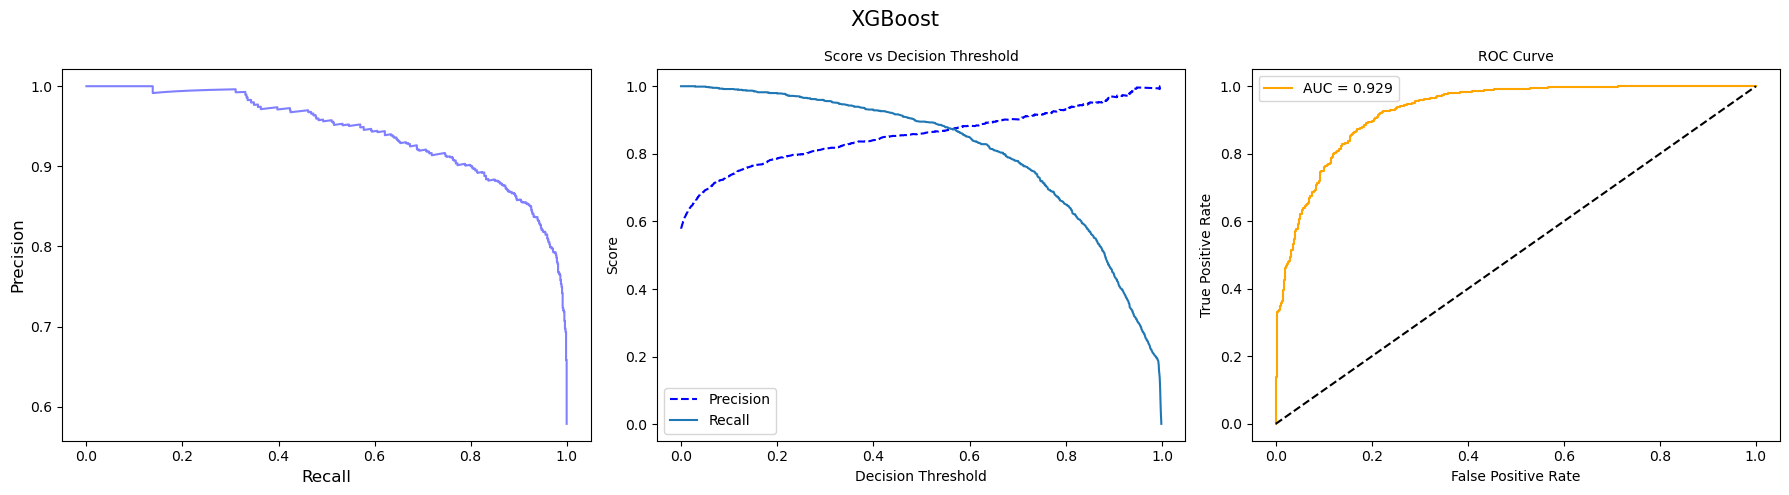

In [37]:
plot_binary_eval_curves(
    y_test_type,
    xgb_binary_scores,
    model='XGBoost',
    figsize=(18,5)
)

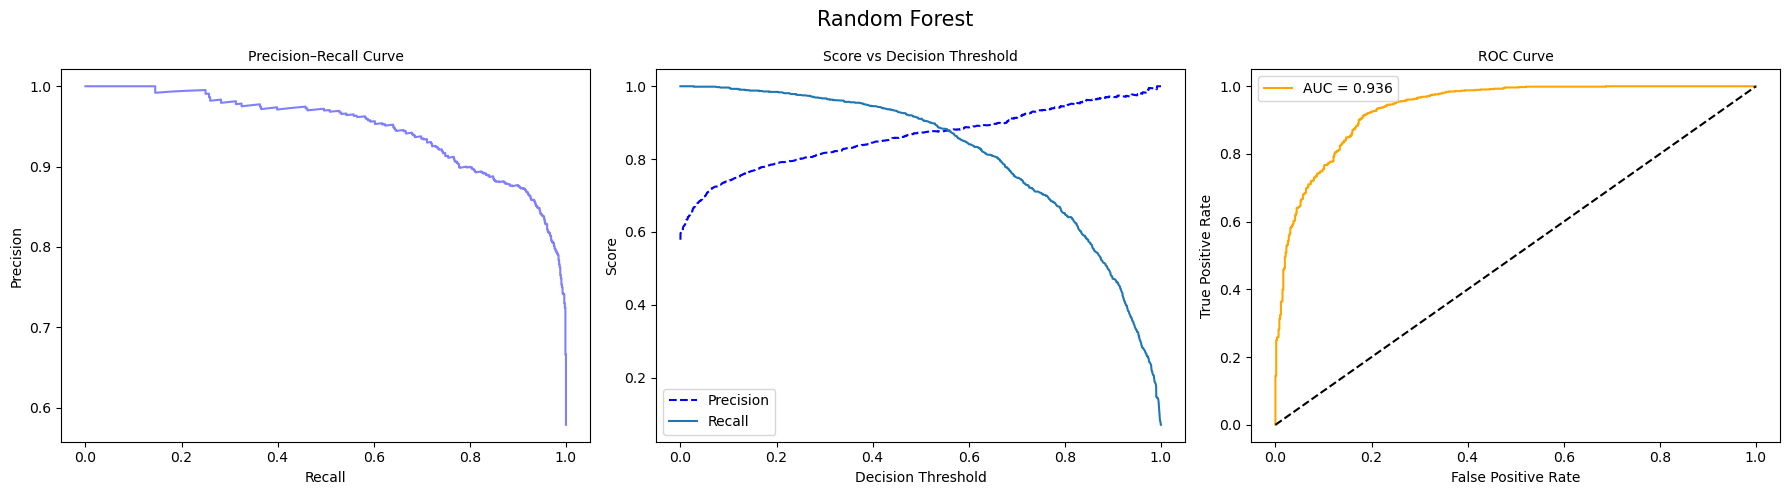

In [124]:
plot_binary_eval_curves(
    y_test_type,
    rf_binary_scores,
    model='Random Forest'
)

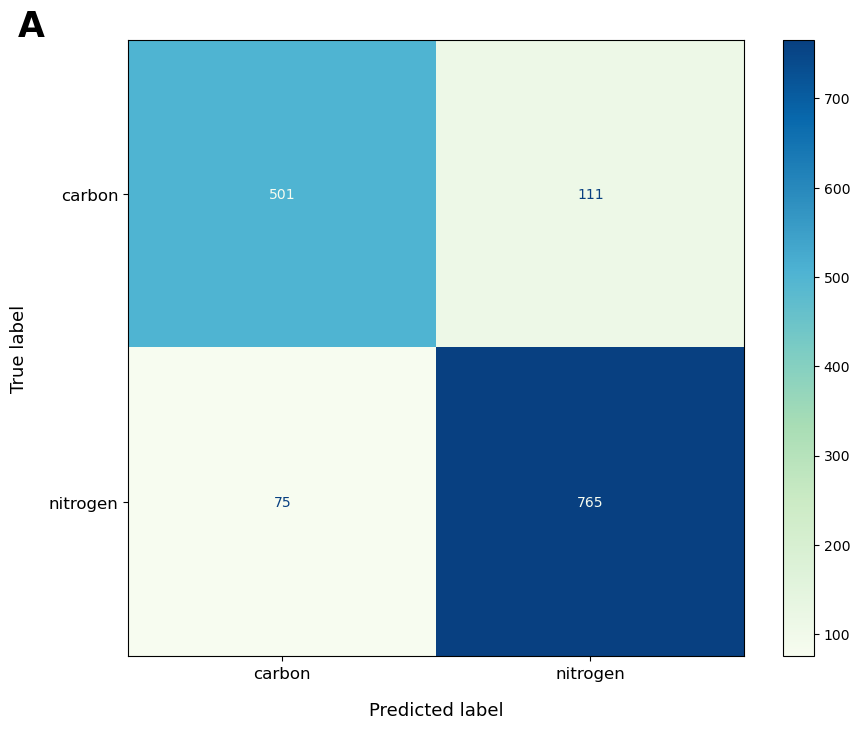

In [26]:
cm = confusion_matrix(y_test_type, rf_binary_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_type.classes_)

# disp.plot(cmap='GnBu')
# plt.title("Stage 1: Random Forest")
# plt.show()

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(cmap='GnBu', ax=ax)
# ax.set_title("Stage 1: Random Forest", fontsize=15, pad=15)
ax.text(-0.18, 1.05, "A", transform=ax.transAxes, fontsize=25, fontweight="bold", va="top")
ax.set_xlabel("Predicted label", fontsize=13, labelpad=15)
ax.set_ylabel("True label", fontsize=13, labelpad=15)
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=12)
plt.show()

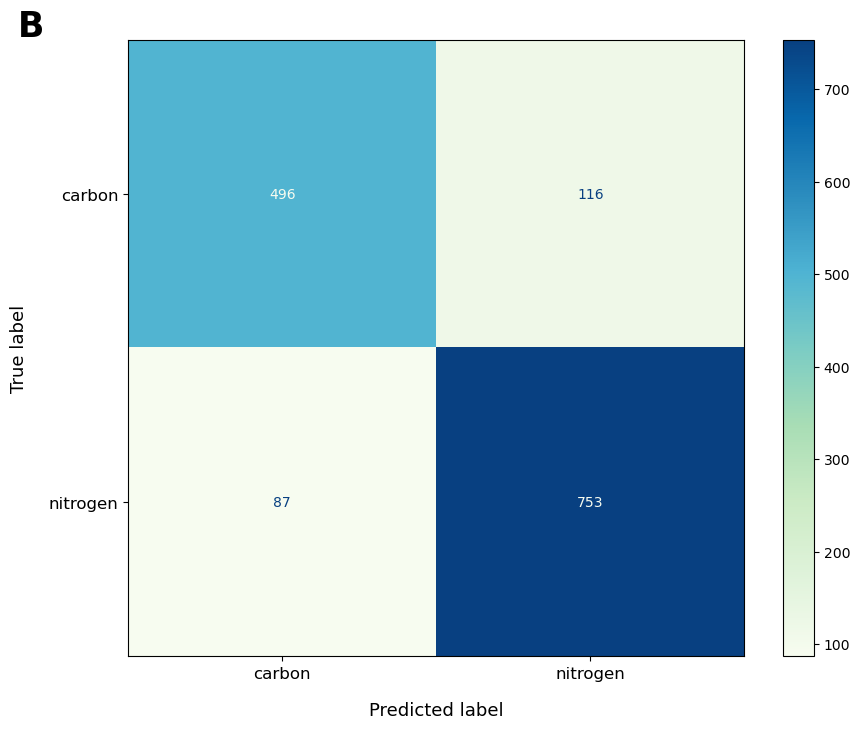

In [38]:
cm = confusion_matrix(y_test_type, xgb_binary_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_type.classes_)

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(cmap='GnBu', ax=ax)
# ax.set_title("Stage 1: XGBoost", fontsize=15, pad=15)
ax.text(-0.18, 1.05, "B", transform=ax.transAxes, fontsize=25, fontweight="bold", va="top")
ax.set_xlabel("Predicted label", fontsize=13, labelpad=15)
ax.set_ylabel("True label", fontsize=13, labelpad=15)
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=12)
plt.show()

**Stage 2**

In [39]:
def evaluate_stage2_predictions(y_true, y_pred, name, label_encoder):
    print(f"\n=== {name} ===")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print(
        "Precision:",
        precision_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    print(
        "Recall   :",
        recall_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    print(
        "F1       :",
        f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0
        )
    )

    print(
        "MCC      :",
        matthews_corrcoef(y_true, y_pred)
    )

    print("\nClassification report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=label_encoder.classes_,
            zero_division=0
        )
    )

In [40]:
rf_c_pred = best_rf_carbon.predict(X_c_test)
rf_n_pred = best_rf_nitrogen.predict(X_n_test)

xgb_c_pred = best_xgb_carbon.predict(X_c_test)
xgb_n_pred = best_xgb_nitrogen.predict(X_n_test)

In [39]:
evaluate_stage2_predictions(
    y_c_test,
    rf_c_pred,
    "RF Stage 2 carbon",
    le_carbon
)

evaluate_stage2_predictions(
    y_n_test,
    rf_n_pred,
    "RF Stage 2 nitrogen",
    le_nitrogen
)


=== RF Stage 2 carbon ===
Accuracy : 0.8137254901960784
Precision: 0.8301572720530013
Recall   : 0.8146396973722826
F1       : 0.8204027949910022
MCC      : 0.7653477291173942

Classification report:
              precision    recall  f1-score   support

          ac       0.88      0.85      0.87        96
         glc       0.80      0.81      0.81       141
        glyc       0.80      0.68      0.73       116
        lcts       0.73      0.85      0.78       157
        succ       0.94      0.88      0.91       102

    accuracy                           0.81       612
   macro avg       0.83      0.81      0.82       612
weighted avg       0.82      0.81      0.81       612


=== RF Stage 2 nitrogen ===
Accuracy : 0.8821428571428571
Precision: 0.8893945617349872
Recall   : 0.8697391846998146
F1       : 0.8776763066839376
MCC      : 0.8164852182942675

Classification report:
              precision    recall  f1-score   support

         arg       0.86      0.94      0.90       38

In [85]:
evaluate_stage2_predictions(
    y_c_test,
    xgb_c_pred,
    "XGBBoost Stage 2 carbon",
    le_carbon
)

evaluate_stage2_predictions(
    y_n_test,
    xgb_n_pred,
    "XGBBoost Stage 2 nitrogen",
    le_nitrogen
)


=== XGBBoost Stage 2 carbon ===
Accuracy : 0.8218954248366013
Precision: 0.8393375674817403
Recall   : 0.8223294248631128
F1       : 0.8284165619928052
MCC      : 0.7761319046551034

Classification report:
              precision    recall  f1-score   support

          ac       0.90      0.84      0.87        96
         glc       0.84      0.80      0.82       141
        glyc       0.81      0.70      0.75       116
        lcts       0.72      0.87      0.79       157
        succ       0.92      0.90      0.91       102

    accuracy                           0.82       612
   macro avg       0.84      0.82      0.83       612
weighted avg       0.83      0.82      0.82       612


=== XGBBoost Stage 2 nitrogen ===
Accuracy : 0.8797619047619047
Precision: 0.8831139894976747
Recall   : 0.8705519764574884
F1       : 0.8755554430251548
MCC      : 0.8125709028302317

Classification report:
              precision    recall  f1-score   support

         arg       0.87      0.93      0

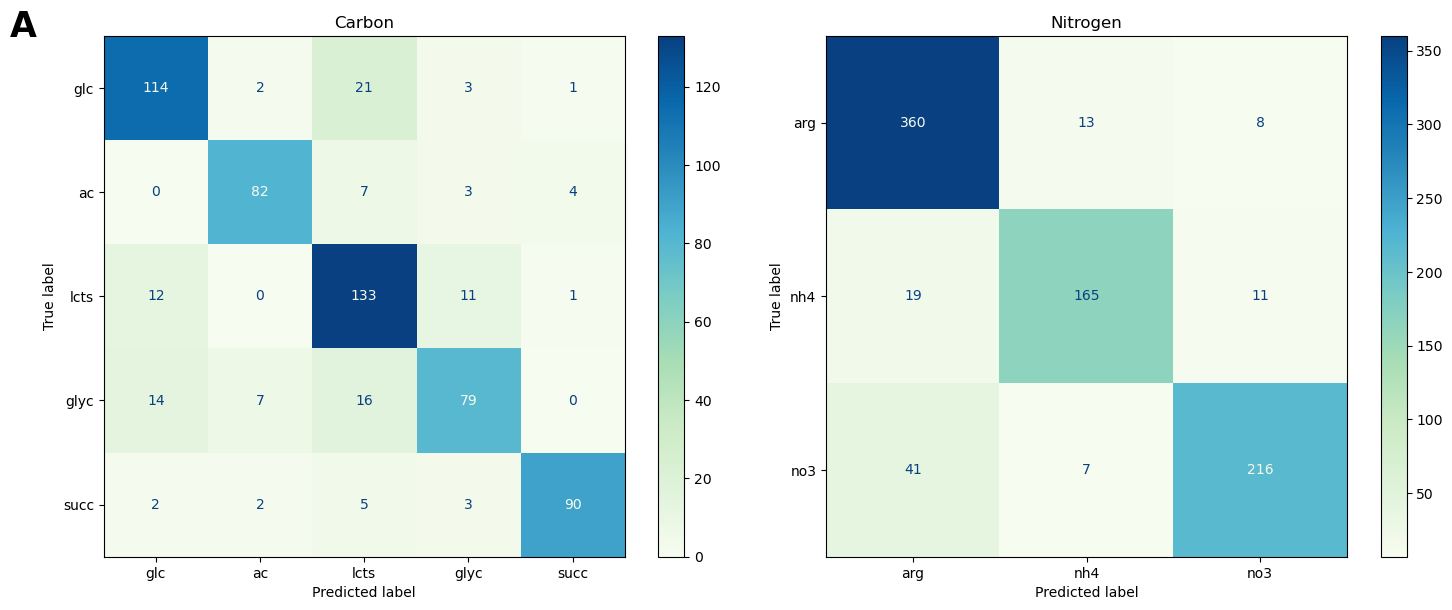

In [45]:
c_order = ['glc', 'ac', 'lcts', 'glyc', 'succ']
n_order = ['arg', 'nh4', 'no3']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm_carbon = confusion_matrix(le_carbon.inverse_transform(y_c_test), le_carbon.inverse_transform(rf_c_pred), labels=c_order)
disp_carbon = ConfusionMatrixDisplay(cm_carbon, display_labels=c_order)

disp_carbon.plot(
    cmap='GnBu',
    ax=axes[0],
    colorbar=True
)

axes[0].set_title("Carbon")

cm_nitrogen = confusion_matrix(le_nitrogen.inverse_transform(y_n_test), le_nitrogen.inverse_transform(rf_n_pred), labels=n_order)
disp_nitrogen = ConfusionMatrixDisplay(cm_nitrogen,display_labels=n_order)

disp_nitrogen.plot(cmap='GnBu',ax=axes[1],colorbar=True)

axes[1].set_title("Nitrogen")
axes[0].text(-0.18, 1.05, "A", transform=axes[0].transAxes, fontsize=25, fontweight="bold", va="top")

# plt.suptitle('Stage 2: Random Forest', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

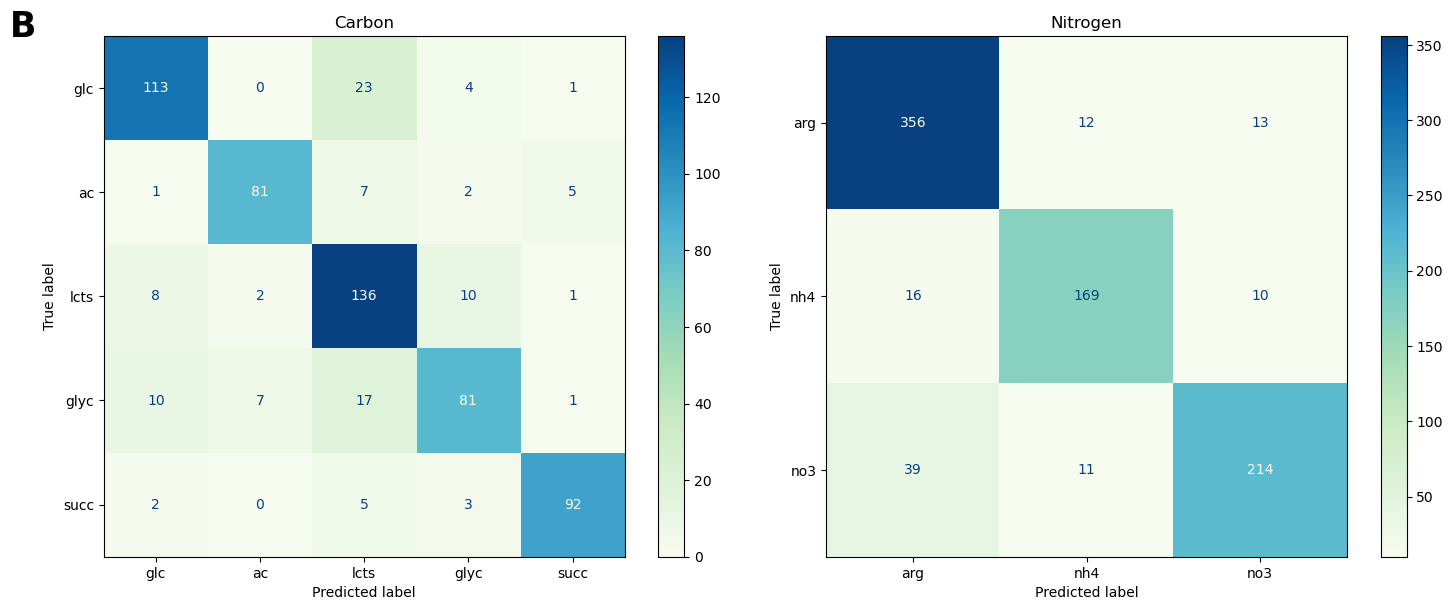

In [59]:
c_order = ['glc', 'ac', 'lcts', 'glyc', 'succ']
n_order = ['arg', 'nh4', 'no3']

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cm_carbon = confusion_matrix(le_carbon.inverse_transform(y_c_test), le_carbon.inverse_transform(xgb_c_pred), labels=c_order)
disp_carbon = ConfusionMatrixDisplay(cm_carbon, display_labels=c_order)

disp_carbon.plot(
    cmap='GnBu',
    ax=axes[0],
    colorbar=True
)

axes[0].set_title("Carbon")

cm_nitrogen = confusion_matrix(le_nitrogen.inverse_transform(y_n_test), le_nitrogen.inverse_transform(xgb_n_pred), labels=n_order)
disp_nitrogen = ConfusionMatrixDisplay(cm_nitrogen,display_labels=n_order)

disp_nitrogen.plot(cmap='GnBu',ax=axes[1],colorbar=True)

axes[1].set_title("Nitrogen")

axes[0].text(-0.18, 1.05, "B", transform=axes[0].transAxes, fontsize=25, fontweight="bold", va="top")
# plt.suptitle('Stage 2: XGBoost', fontsize=15)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

**Full pipeline**

In [87]:
evaluate_predictions(
    y_test_source,
    rf_source_pred,
    "RF full pipeline: final source"
)

evaluate_predictions(
    y_test_source,
    xgb_source_pred,
    "XGBBoost full pipeline: final source"
)


=== RF full pipeline: final source ===
Accuracy : 0.7493112947658402
Precision: 0.7400497036488052
Recall   : 0.6991064183685247
F1       : 0.7063490800065229
MCC      : 0.7019583817070539

Classification report:
              precision    recall  f1-score   support

          ac       0.68      0.31      0.43        96
         arg       0.76      0.87      0.81       381
         glc       0.67      0.72      0.69       141
        glyc       0.72      0.49      0.58       116
        lcts       0.65      0.82      0.73       157
         nh4       0.80      0.75      0.78       195
         no3       0.82      0.79      0.80       264
        succ       0.83      0.84      0.83       102

    accuracy                           0.75      1452
   macro avg       0.74      0.70      0.71      1452
weighted avg       0.75      0.75      0.74      1452


=== XGBBoost full pipeline: final source ===
Accuracy : 0.7410468319559229
Precision: 0.7249797267477234
Recall   : 0.6889508108476816

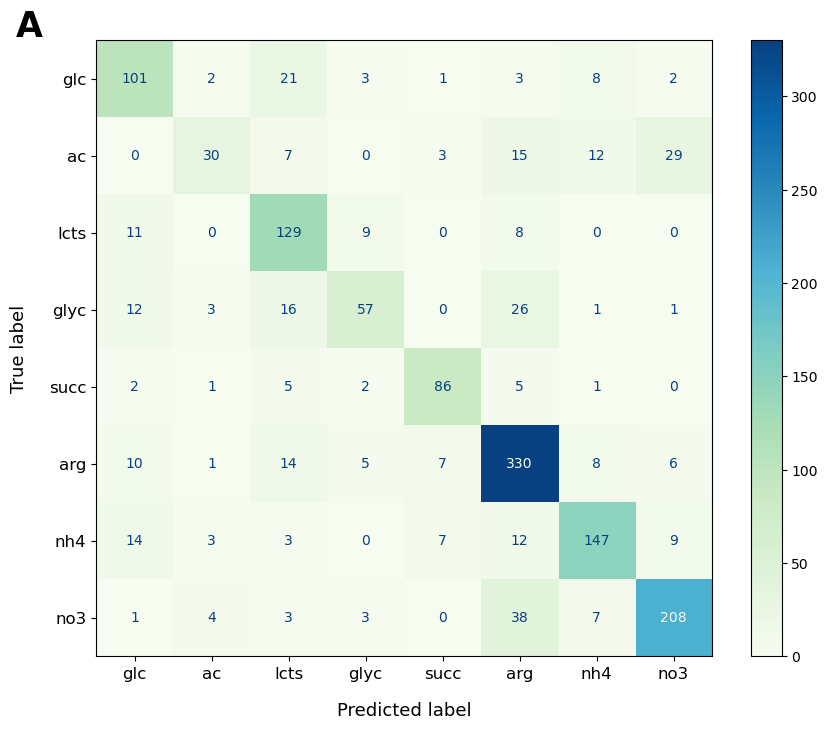

In [57]:
env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg', 'nh4', 'no3']

cm = confusion_matrix(y_test_source, rf_source_pred, labels=env_order)
disp = ConfusionMatrixDisplay(cm, display_labels=env_order)

fig, ax = plt.subplots(figsize=(10,8))
disp.plot(cmap='GnBu', ax=ax)
# ax.set_title("Full pipeline: Random Forest", fontsize=15, pad=15)
ax.text(-0.13, 1.05, "A", transform=ax.transAxes, fontsize=25, fontweight="bold", va="top")
ax.set_xlabel("Predicted label", fontsize=13, labelpad=15)
ax.set_ylabel("True label", fontsize=13, labelpad=15)
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=12)
plt.show()

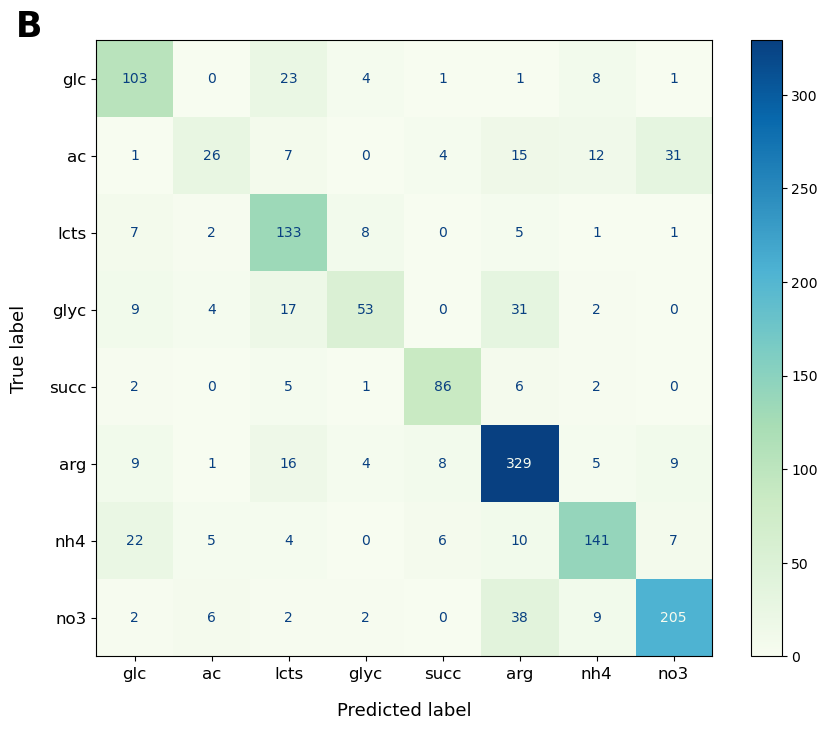

In [56]:
env_order = ['glc', 'ac', 'lcts', 'glyc', 'succ', 'arg', 'nh4', 'no3']

cm = confusion_matrix(y_test_source, xgb_source_pred, labels=env_order)
disp = ConfusionMatrixDisplay(cm, display_labels=env_order)


fig, ax = plt.subplots(figsize=(10,8))
disp.plot(cmap='GnBu', ax=ax)
# ax.set_title("Full pipeline: XGBoost", fontsize=15, pad=15)
ax.text(-0.13, 1.05, "B", transform=ax.transAxes, fontsize=25, fontweight="bold", va="top")
ax.set_xlabel("Predicted label", fontsize=13, labelpad=15)
ax.set_ylabel("True label", fontsize=13, labelpad=15)
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=12)
plt.show()

In [89]:
rf_source_proba = make_prediction_proba(
    X_test,
    best_rf_binary,
    best_rf_carbon,
    best_rf_nitrogen,
    le_type,
    le_source,
    le_carbon,
    le_nitrogen
)

xgb_source_proba = make_prediction_proba(
    X_test,
    best_xgb_binary,
    best_xgb_carbon,
    best_xgb_nitrogen,
    le_type,
    le_source,
    le_carbon,
    le_nitrogen
)

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_final_pipeline_multiclass_roc(y_true_encoded, y_score, label_encoder, title):
    classes = np.arange(len(label_encoder.classes_))

    y_true_bin = label_binarize(
        y_true_encoded,
        classes=classes
    )

    plt.figure(figsize=(8, 6))

    for i, class_name in enumerate(label_encoder.classes_):
        if y_true_bin[:, i].sum() == 0:
            print(f"Skipping {class_name}: no positive samples in test set")
            continue

        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f"{class_name} AUC = {roc_auc:.2f}"
        )

    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate", fontsize=13)
    plt.ylabel("True Positive Rate", fontsize=13)
    plt.title(title)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

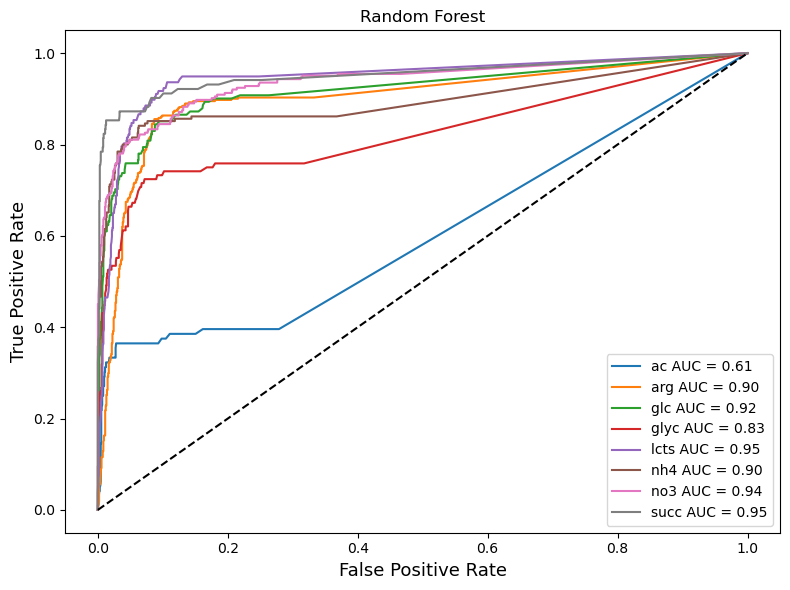

In [23]:
y_test_source_encoded = le_source.transform(y_test_source)

plot_final_pipeline_multiclass_roc(
    y_test_source_encoded,
    rf_source_proba,
    le_source,
    "Random Forest"
)

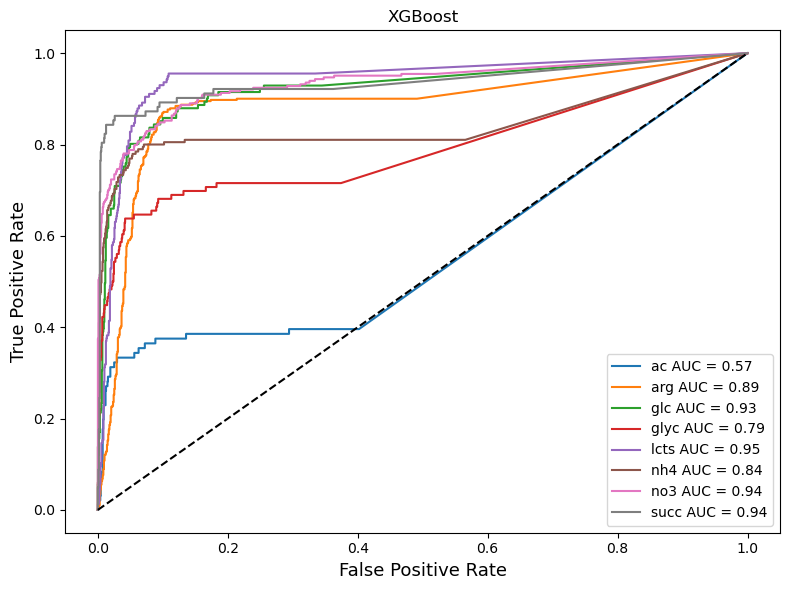

In [90]:
y_test_source_encoded = le_source.transform(y_test_source)

plot_final_pipeline_multiclass_roc(
    y_test_source_encoded,
    xgb_source_proba,
    le_source,
    "XGBoost"
)

## Permutation importance

In [78]:
import matplotlib.ticker as mticker

def get_permutation_importance(model, X_val, y_val, feature_names, model_name, stage_name,
                                n_repeats=30, random_state=42, scoring="f1_macro"):
    result = permutation_importance(
        model, X_val, y_val,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1,
        scoring=scoring
    )
    return pd.DataFrame({
        "feature":    feature_names,
        "importance": result.importances_mean,
        "std":        result.importances_std,
        "scores":     list(result.importances),
        "model":      model_name,
        "stage":      stage_name
    }).sort_values("importance", ascending=False)


def format_feature_label(name):
    return name.replace("_biomass_to_biomass", "")

def plot_permutation_importance(fi_df, title=None, palette="crest",
                                style="bar", scoring="f1_macro"):
    plot_df = (fi_df
               .sort_values("importance", ascending=True)
               .reset_index(drop=True))

    plot_df["feature"] = plot_df["feature"].apply(format_feature_label)

    n = len(plot_df)
    # fig, ax = plt.subplots(figsize=(12, 6))

    if style == "box":
        box_data = list(plot_df["scores"])
        bp = ax.boxplot(
            box_data,
            vert=False,
            patch_artist=True,
            labels=plot_df["feature"],
            medianprops=dict(linewidth=1.5), 
            whiskerprops=dict(linewidth=0.8),
            capprops=dict(linewidth=0.8),
            flierprops=dict(marker="o", markersize=5, alpha=0.8),
            widths=0.8
        )
        cmap = sns.color_palette(palette, as_cmap=True)
        for i, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(cmap(i / (n - 1)))
            patch.set_alpha(0.8)
            patch.set_linewidth(0.6)

    else:  # bar (default)
        cmap = sns.color_palette(palette, as_cmap=True)
        colors = [cmap(i / (n - 1)) for i in range(n)]
        bars = ax.barh(
            plot_df["feature"],
            plot_df["importance"],
            xerr=plot_df["std"],
            color=colors,
            error_kw=dict(ecolor="#555555", elinewidth=0.8, capsize=3, capthick=0.8),
            height=0.65,
        )
        for bar, val in zip(bars, plot_df["importance"]):
            if val < 0:
                bar.set_facecolor("#d9534f")
                bar.set_alpha(0.6)

    ax.axvline(0, color="k", linewidth=0.8, linestyle="--")

    if scoring != "f1_macro":
        ax.set_xlabel(f"Decrease in MCC score", fontsize=13)
    else:
        ax.set_xlabel(f"Decrease in F1 Score (macro)", fontsize=13)
    ax.set_title(title or f"{fi_df['model'].iloc[0]} ({fi_df['stage'].iloc[0]})",
                 fontsize=15, pad=12)


    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.tick_params(axis="y", labelsize=12)
    ax.tick_params(axis="x", labelsize=10)
    # ax.spines[["top", "right"]].set_visible(False)
    # ax.spines[["left", "bottom"]].set_linewidth(0.6)
    ax.grid(axis="x", linewidth=0.8, linestyle=":", color="#aaaaaa")

    plt.tight_layout()
    plt.show()

In [65]:
feature_names = X.columns.tolist()

fi_rf_binary = get_permutation_importance(
    best_rf_binary, X_test, y_test_type,
    feature_names, "Random Forest", "Stage 1", scoring="matthews_corrcoef"
)

fi_rf_carbon = get_permutation_importance(
    best_rf_carbon, X_c_test, y_c_test,
    feature_names, "Random Forest", "Stage 2 carbon", scoring="f1_macro"
)

fi_rf_nitrogen = get_permutation_importance(
    best_rf_nitrogen, X_n_test, y_n_test,
    feature_names, "Random Forest", "Stage 2 nitrogen", scoring="f1_macro"
)

In [79]:
fi_xgb_binary = get_permutation_importance(
    best_xgb_binary, X_test, y_test_type,
    feature_names, "XGBoost", "Stage 1", scoring="matthews_corrcoef"
)

fi_xgb_carbon = get_permutation_importance(
    best_xgb_carbon, X_c_test, y_c_test,
    feature_names, "XGBoost", "Stage 2 carbon", scoring="f1_macro"
)

fi_xgb_nitrogen = get_permutation_importance(
    best_xgb_nitrogen, X_n_test, y_n_test,
    feature_names, "XGBoost", "Stage 2 nitrogen", scoring="f1_macro"
)

In [ ]:
# for fi, title in [
#     (fi_rf_binary,   "Stage 1 — Random Forest"),
#     (fi_xgb_binary,  "Stage 1 — XGBoost"),
# ]:
#     plot_permutation_importance(fi, style="box", scoring="mcc")

/triumvirate/apps/.scratch/celinaha/ipykernel_775501/2396194824.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


<Figure size 640x480 with 0 Axes>

/triumvirate/apps/.scratch/celinaha/ipykernel_775501/2396194824.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


<Figure size 640x480 with 0 Axes>

In [63]:
# for fi, title in [
#     (fi_rf_carbon,   "Stage 2 Carbon — Random Forest"),
#     (fi_xgb_carbon,  "Stage 2 Carbon — XGBoost"),
#     (fi_rf_nitrogen, "Stage 2 Nitrogen — Random Forest"),
#     (fi_xgb_nitrogen,"Stage 2 Nitrogen — XGBoost"),
# ]:
#     plot_permutation_importance(fi, style="box")

In [2]:
# print("\n=== RF Stage 1 ===")
# print(fi_rf_binary)

# print("\n=== RF Stage 2 Carbon ===")
# print(fi_rf_carbon)

# print("\n=== RF Stage 2 Nitrogen ===")
# print(fi_rf_nitrogen)

# print("\n=== XGBoost Stage 1 ===")
# print(fi_xgb_binary)

# print("\n=== XGBoost Stage 2 Carbon ===")
# print(fi_xgb_carbon)

# print("\n=== XGBoost Stage 2 Nitrogen ===")
# print(fi_xgb_nitrogen)

/triumvirate/apps/.scratch/celinaha/ipykernel_775501/880880289.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/triumvirate/apps/.scratch/celinaha/ipykernel_775501/880880289.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/triumvirate/apps/.scratch/celinaha/ipykernel_775501/880880289.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


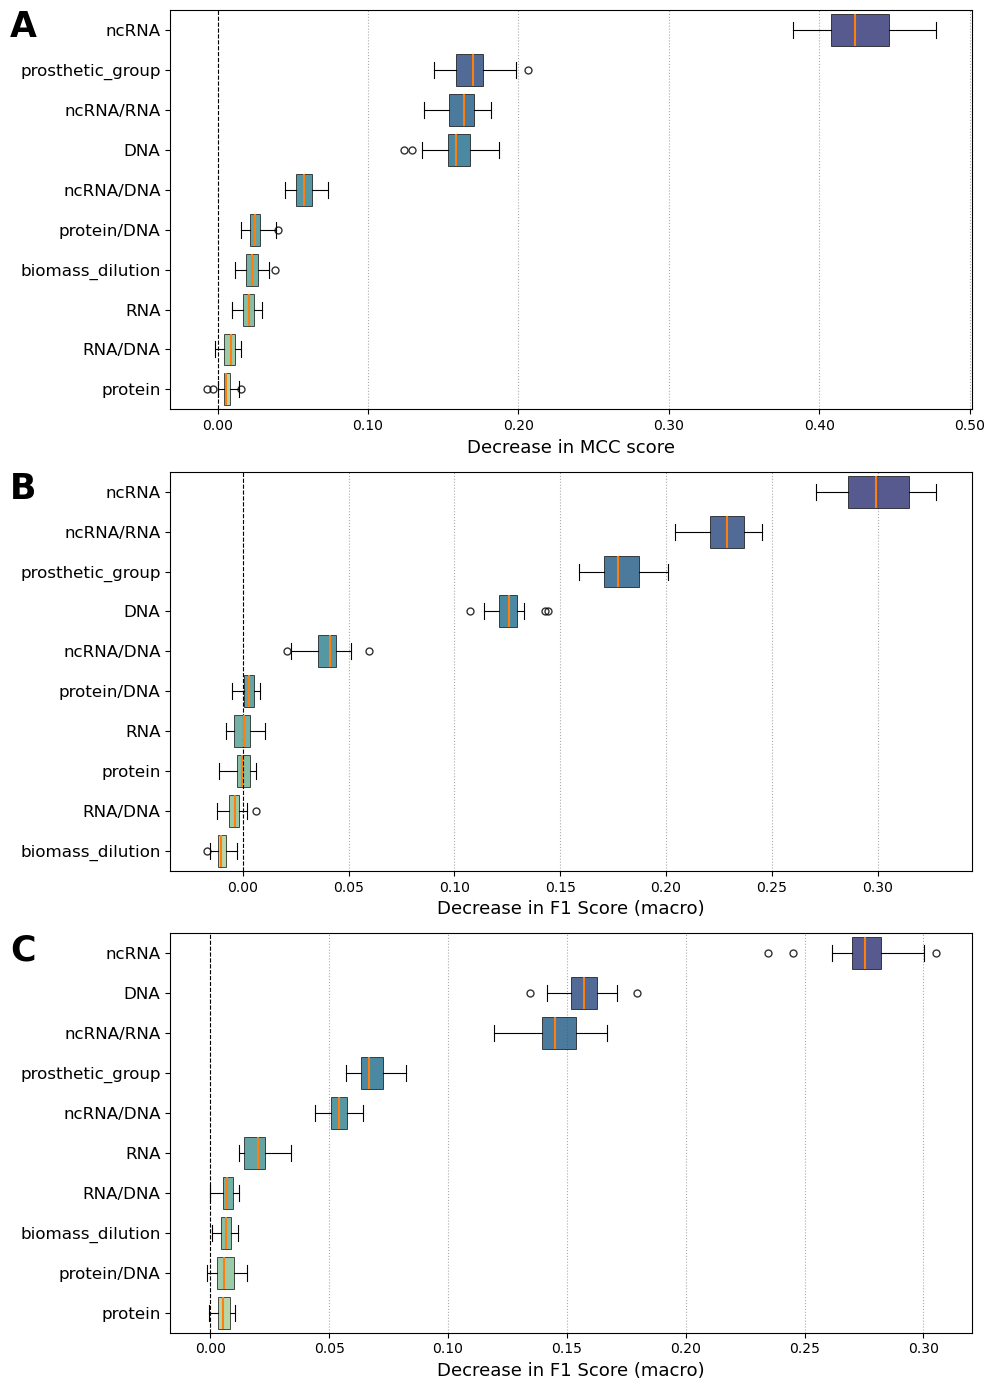

In [73]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 14)
)

plot_permutation_importance(
    fi_rf_binary,
    ax=axes[0],
    panel_label="A",
    scoring="matthews_corrcoef",
    style="box"
)

plot_permutation_importance(
    fi_rf_carbon,
    ax=axes[1],
    panel_label="B",
    scoring="f1_macro",
    style="box"
)

plot_permutation_importance(
    fi_rf_nitrogen,
    ax=axes[2],
    panel_label="C",
    scoring="f1_macro",
    style="box"
)

plt.tight_layout()
plt.show()

In [76]:
plot_permutation_importance(
    fi_rf_binary,
    panel_label="A",
    style="box",
    scoring="matthews_corrcoef"
)

plot_permutation_importance(
    fi_rf_carbon,
    panel_label="B",
    style="box",
    scoring="f1_macro"
)

plot_permutation_importance(
    fi_rf_nitrogen,
    panel_label="C",
    style="box",
    scoring="f1_macro"
)

/triumvirate/apps/.scratch/celinaha/ipykernel_775501/1227531983.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/triumvirate/apps/.scratch/celinaha/ipykernel_775501/1227531983.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
/triumvirate/apps/.scratch/celinaha/ipykernel_775501/1227531983.py:38: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


In [85]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

def plot_permutation_importance(
    fi_df,
    panel_label=None,
    palette="crest",
    style="box",
    scoring="f1_macro",
    figsize=(12, 6)
):
    plot_df = (
        fi_df
        .sort_values("importance", ascending=True)
        .reset_index(drop=True)
    )

    plot_df["feature"] = plot_df["feature"].apply(format_feature_label)

    n = len(plot_df)
    fig, ax = plt.subplots(figsize=figsize)

    cmap = sns.color_palette(palette, as_cmap=True)

    if style == "box":
        box_data = list(plot_df["scores"])

        bp = ax.boxplot(
            box_data,
            vert=False,
            patch_artist=True,
            tick_labels=plot_df["feature"],  # use labels=... if older matplotlib
            medianprops=dict(linewidth=1.5),
            whiskerprops=dict(linewidth=0.8),
            capprops=dict(linewidth=0.8),
            flierprops=dict(marker="o", markersize=5, alpha=0.8),
            widths=0.8
        )

        for i, patch in enumerate(bp["boxes"]):
            patch.set_facecolor(cmap(i / max(n - 1, 1)))
            patch.set_alpha(0.8)
            patch.set_linewidth(0.6)

    else:
        colors = [cmap(i / max(n - 1, 1)) for i in range(n)]

        bars = ax.barh(
            plot_df["feature"],
            plot_df["importance"],
            xerr=plot_df["std"],
            color=colors,
            error_kw=dict(ecolor="#555555", elinewidth=0.8, capsize=3, capthick=0.8),
            height=0.65,
        )

        for bar, val in zip(bars, plot_df["importance"]):
            if val < 0:
                bar.set_facecolor("#d9534f")
                bar.set_alpha(0.6)

    ax.axvline(0, color="k", linewidth=0.8, linestyle="--")

    if scoring != "f1_macro":
        ax.set_xlabel("Decrease in MCC score", fontsize=13)
    else:
        ax.set_xlabel("Decrease in F1 Score (macro)", fontsize=13)

    # No title — only A, B, C label
    if panel_label is not None:
        ax.text(
            -0.18, 1.05, panel_label,
            transform=ax.transAxes,
            fontsize=25,
            fontweight="bold",
            va="top"
        )

    ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
    ax.tick_params(axis="y", labelsize=12)
    ax.tick_params(axis="x", labelsize=10)
    ax.grid(axis="x", linewidth=0.8, linestyle=":", color="#aaaaaa")

    plt.tight_layout()
    plt.show()

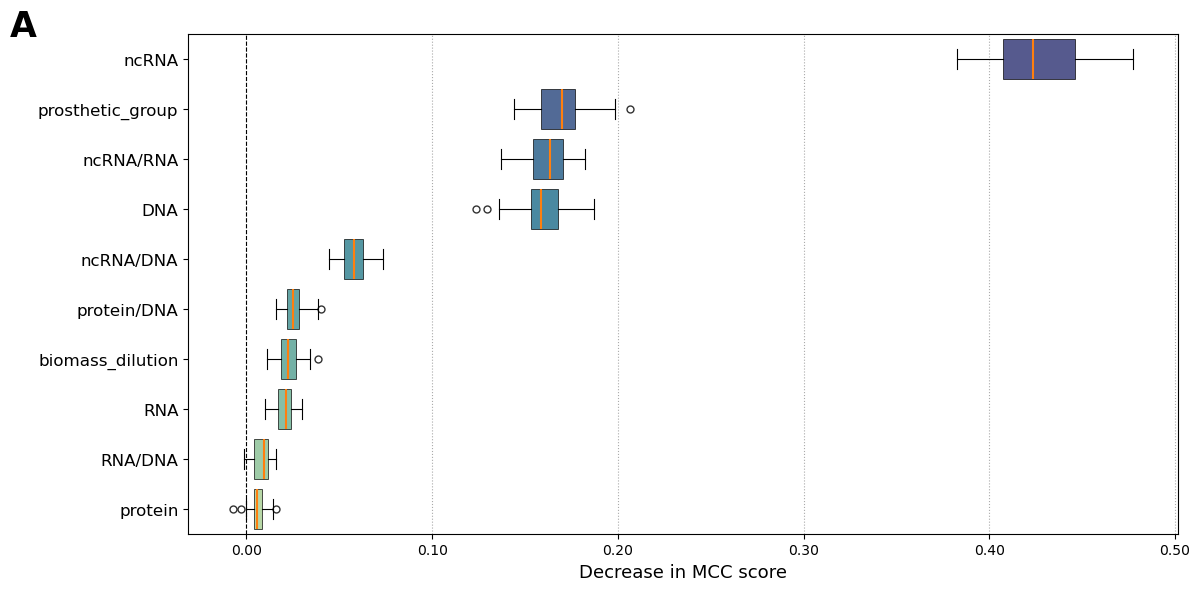

In [86]:
plot_permutation_importance(
    fi_rf_binary,
    panel_label="A",
    style="box",
    scoring="matthews_corrcoef"
)

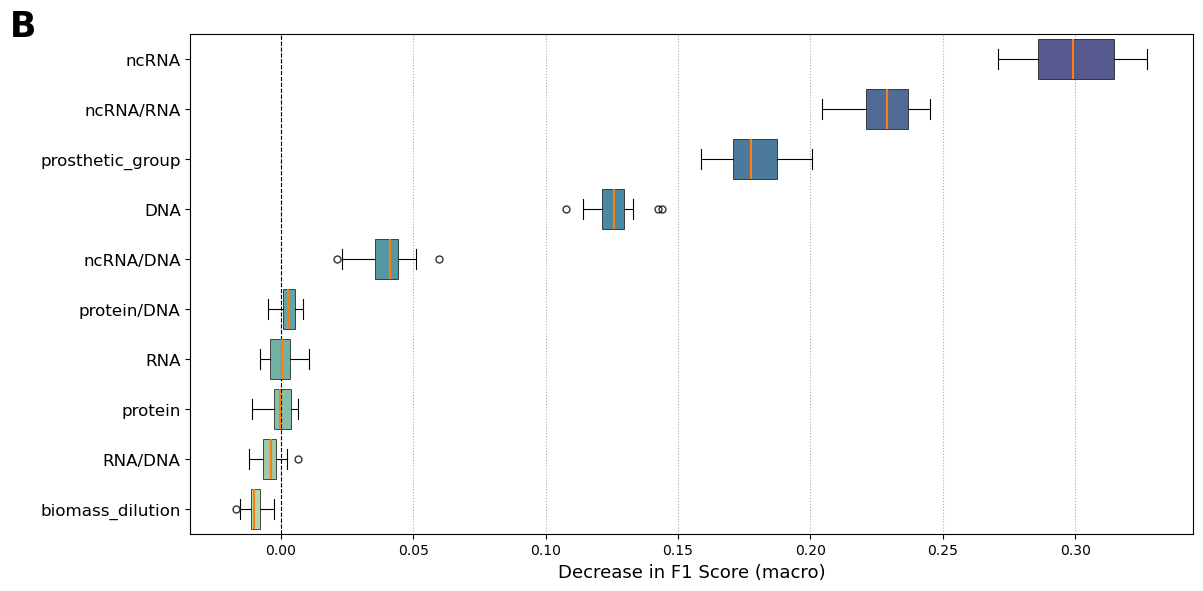

In [87]:
plot_permutation_importance(
    fi_rf_carbon,
    panel_label="B",
    style="box",
    scoring="f1_macro"
)

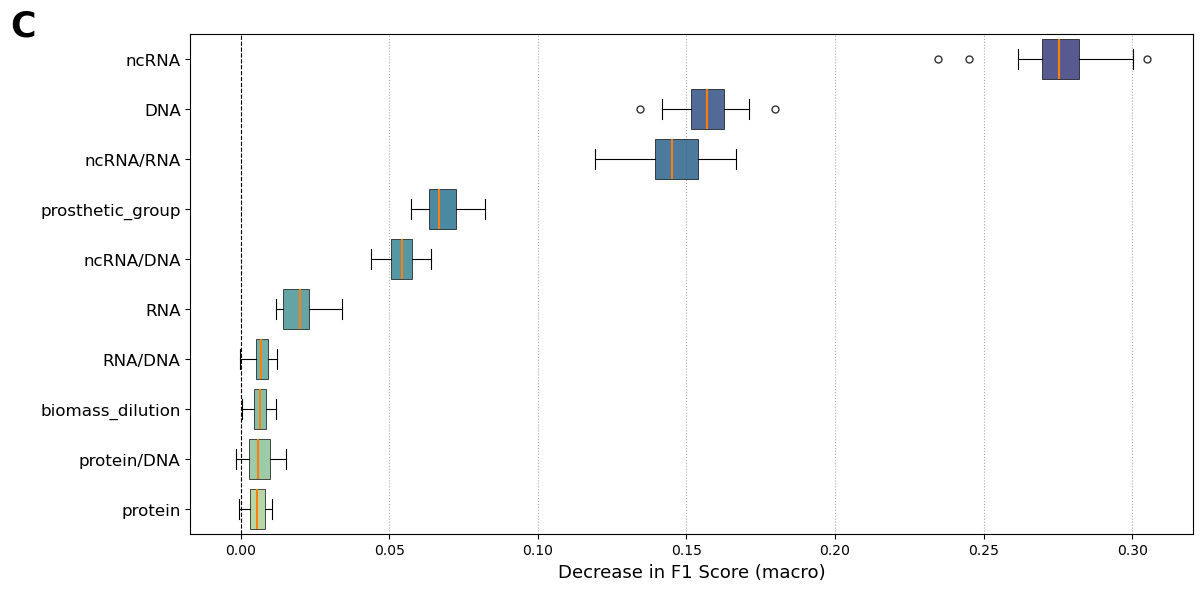

In [88]:
plot_permutation_importance(
    fi_rf_nitrogen,
    panel_label="C",
    style="box",
    scoring="f1_macro"
)